import data

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore.xlsx to Sample - Superstore.xlsx


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("Sample - Superstore.xlsx")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


In [ ]:
df.shape

(9994, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9988 non-null   float64
 18  Quantity

Convert the date

In [ ]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

Create month and year:

In [ ]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Year-Month"] = df["Order Date"].dt.to_period("M")

Revenue trend in Python

In [ ]:
monthly_sales = (
    df.groupby("Year-Month")["Sales"]
      .sum()
      .reset_index()
)

monthly_sales["Year-Month"] = monthly_sales["Year-Month"].astype(str)

monthly_sales.head()

,Year-Month,Sales
0,2014-01,14236.895
1,2014-02,4519.892
2,2014-03,55691.009
3,2014-04,28178.561
4,2014-05,23648.287


Create the chart:

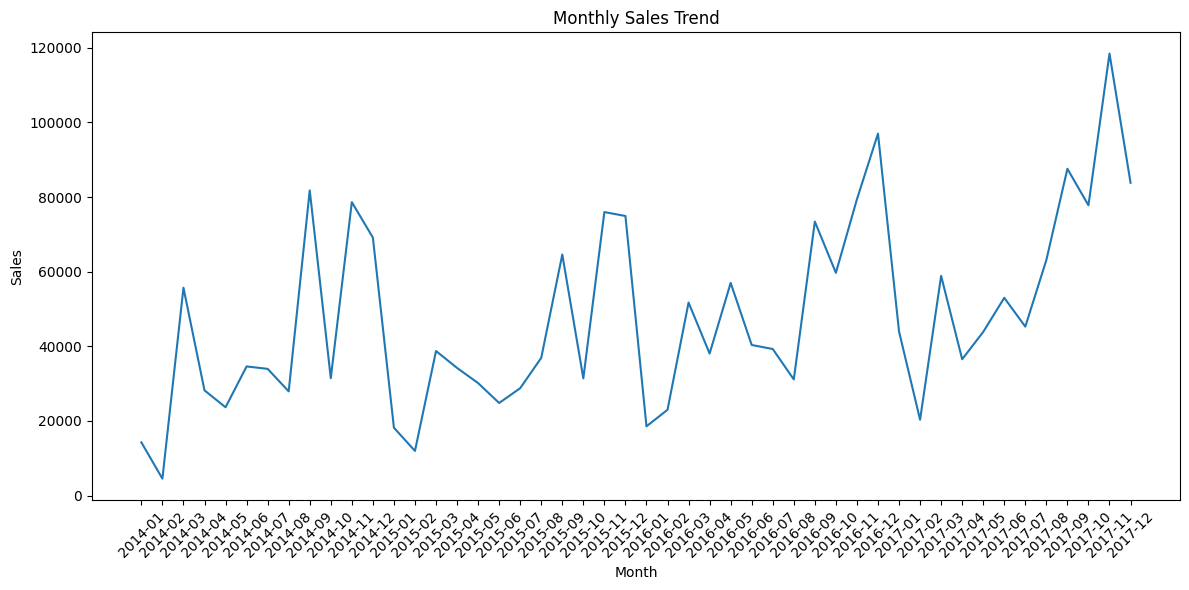

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales["Year-Month"],
    monthly_sales["Sales"]
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Top 10 products

In [ ]:
top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


Top 10 products chart

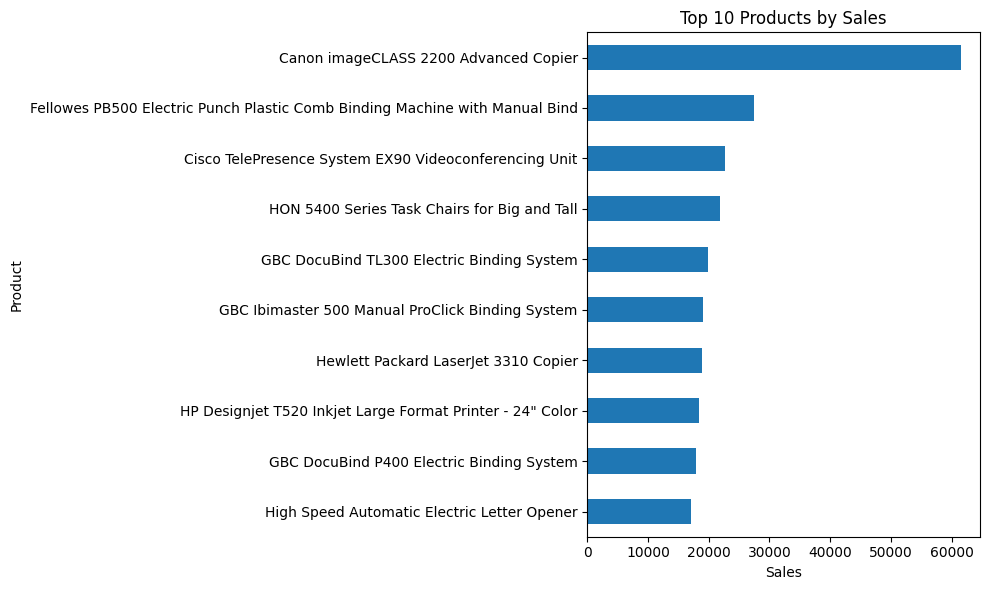

In [ ]:
top_products.sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

Category analysis

In [ ]:
category_sales = (
    df.groupby("Category")[["Sales", "Profit"]]
      .sum()
      .sort_values("Sales", ascending=False)
)

print(category_sales)

                       Sales       Profit
Category                                 
Technology       834227.0970  145046.2041
Furniture        741999.7953   18451.2728
Office Supplies  719047.0320  122490.8008


profit margin

In [ ]:
category_sales["Profit Margin"] = (
    category_sales["Profit"] /
    category_sales["Sales"] * 100
)

print(category_sales)

                       Sales       Profit  Profit Margin
Category                                                
Technology       834227.0970  145046.2041      17.386897
Furniture        741999.7953   18451.2728       2.486695
Office Supplies  719047.0320  122490.8008      17.035158


Regional analysis

In [ ]:
region_analysis = (
    df.groupby("Region")[["Sales", "Profit"]]
      .sum()
      .sort_values("Sales", ascending=False)
)

print(region_analysis)

               Sales       Profit
Region                           
West     725457.8245  108418.4489
East     678664.4560   91500.8830
Central  500130.4428   39450.8975
South    391021.2010   46618.0483


In [ ]:
region_analysis["Profit Margin"] = (
    region_analysis["Profit"] /
    region_analysis["Sales"] * 100
)

print(region_analysis)

               Sales       Profit  Profit Margin
Region                                          
West     725457.8245  108418.4489      14.944831
East     678664.4560   91500.8830      13.482492
Central  500130.4428   39450.8975       7.888122
South    391021.2010   46618.0483      11.922128
